# Meeting 2026-06-26, DPO low-data learning curve

How does **Spearman** (on held-out) change as the number of training
sequences `N` varies, for the different base models (vanilla / evotuned /
C05-specific) used as the DPO starting point?

Two held-out sets:
- **ed5** (N = 50 /	100 /	200 /	500 /	1000 /	2000 /	5000 /	22028 /	220283)
- **ed2 test** (0.01 / 0.1 / 1 / 10 / 100 % of ed2 train = N≈22 / 220 / 2203 / 22028 / 220283).

In [ ]:
# === setup + scan available runs ===================================
%matplotlib inline
import os, re, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import yaml

def _find_repo_root(start: Path) -> Path:
    for d in [start, *start.parents]:
        if (d / "conf" / "analysis" / "models.yaml").exists():
            return d
    raise FileNotFoundError("repo root not found (conf/analysis/models.yaml).")

REPO_ROOT = _find_repo_root(Path.cwd())

def _train_dir() -> Path:
    user = os.environ.get("USER", "unknown")
    scratch = os.environ.get("SCRATCH_DIR", f"/cluster/scratch/{user}/protein-design")
    return Path(os.environ.get("TRAIN_DIR", str(Path(scratch) / "train")))

TRAIN_DIR = _train_dir()
METRIC = "test_spearman_avg"
BASE_NAME_RE = re.compile(r"^lowdata_(?P<model>.+)_n(?P<n>\d+)_s(?P<seed>\d+)$")
ZEROSHOT_RE  = re.compile(r"^zeroshot_(?P<model>.+)_(?P<ts>ed\d)_s(?P<seed>\d+)$")
TS_RE = re.compile(r"_\d{8}_\d{6}$")

# registry for labels/colors consistent with the other figures
_REG = yaml.safe_load((REPO_ROOT / "conf" / "analysis" / "models.yaml").read_text()).get("models", {})
def model_label(key):
    return _REG.get(key, {}).get("label") or key
def model_color(key, i=0):
    c = _REG.get(key, {}).get("color")
    cyc = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    return c if c else cyc[i % len(cyc)]

def _test_set_of(run_dir: Path) -> str:
    """Run's test set, read from resolved_config.yaml (data.test.dataset_key).
    Returns a short label (e.g. 'ed2', 'ed5'); fallback 'ed5' (legacy)."""
    cfg_path = run_dir / "resolved_config.yaml"
    key = "ed5_m22"
    if cfg_path.exists():
        try:
            cfg = yaml.safe_load(cfg_path.read_text())
            key = (((cfg or {}).get("data", {}) or {}).get("test", {}) or {}).get("dataset_key", key)
        except Exception:
            pass
    return str(key).replace("_m22", "")

def scan_runs(train_dir: Path = TRAIN_DIR, metric: str = METRIC) -> pd.DataFrame:
    """Scan $TRAIN_DIR for lowdata_<model>_n<N>_s<seed>. Keeps the most recent run
    for (model, n_train, seed, test_set), so ed2 and ed5 coexist. Runs without
    summary.json (still training) are absent -> ignored."""
    best = {}  # (model, n, seed, test_set) -> (mtime, run_dir, value)
    for p in sorted(train_dir.glob("lowdata_*_n*_s*")):
        summ = p / "summary.json"
        if not summ.exists():
            continue
        m = BASE_NAME_RE.match(TS_RE.sub("", p.name))
        if not m:
            continue
        ts = _test_set_of(p)
        key = (m.group("model"), int(m.group("n")), int(m.group("seed")), ts)
        mt = summ.stat().st_mtime
        if key in best and best[key][0] >= mt:
            continue
        try:
            val = json.loads(summ.read_text()).get(metric)
        except Exception:
            val = None
        best[key] = (mt, str(p), val)
    rows = [{"model": k[0], "n_train": k[1], "seed": k[2], "test_set": k[3],
             metric: v[2], "run_dir": v[1]} for k, v in best.items()]
    cols = ["model", "n_train", "seed", "test_set", metric, "run_dir"]
    if not rows:
        return pd.DataFrame(columns=cols)
    return pd.DataFrame(rows).sort_values(["test_set", "model", "n_train", "seed"]).reset_index(drop=True)

def scan_zero_shot(train_dir: Path = TRAIN_DIR, metric: str = METRIC) -> pd.DataFrame:
    """Scan $TRAIN_DIR for zeroshot_<model>_<ts>_s<seed> dirs (num_epochs=0 DPO runs).
    Returns one row per (model, test_set, seed) with the pre-DPO test Spearman."""
    rows = []
    for p in sorted(train_dir.glob("zeroshot_*_s*")):
        summ = p / "summary.json"
        if not summ.exists():
            continue
        m = ZEROSHOT_RE.match(p.name)
        if not m:
            continue
        try:
            val = json.loads(summ.read_text()).get(metric)
        except Exception:
            val = None
        rows.append({"model": m.group("model"), "test_set": m.group("ts"),
                     "seed": int(m.group("seed")), metric: val})
    cols = ["model", "test_set", "seed", metric]
    if not rows:
        return pd.DataFrame(columns=cols)
    return pd.DataFrame(rows).sort_values(["model", "test_set"]).reset_index(drop=True)

runs_df     = scan_runs()
zeroshot_df = scan_zero_shot()
print(f"TRAIN_DIR = {TRAIN_DIR}")
print(f"Completed DPO runs found: {len(runs_df)}")
print(f"Zero-shot evals found:    {len(zeroshot_df)}"
      + (f"  models: {sorted(zeroshot_df['model'].unique())}" if not zeroshot_df.empty else ""))
print(f"Test sets present: {sorted(runs_df['test_set'].unique()) if not runs_df.empty else []}\n")

if runs_df.empty:
    print("No completed runs.")
else:
    finite = runs_df[pd.to_numeric(runs_df[METRIC], errors="coerce").notna()]
    for ts in sorted(finite["test_set"].unique()):
        sub = finite[finite["test_set"] == ts]
        avail = sub.pivot_table(index="model", columns="n_train", values="seed",
                                aggfunc="count", fill_value=0).astype(int)
        print(f"### Held-out = {ts}  (completed seeds per model x n_train)")
        display(avail)
    print("Available models:", sorted(finite["model"].unique()))


---
## Evotuning *cdrmix*, how Spearman varies with hyperparameters (35M & 650M)

The C05-specific DPO starting point (`evo_c05_cdrmix*`) is produced by a
**single-mask evotuning** run on the CDR-H3 C05 library, optimized to
**maximize masked-position Spearman on ED2/M22** (not perplexity). For
each size I ran a 2×2 sweep over **learning rate** ∈ {2e-5, 5e-5} and
**`cdr_mask_prob`** ∈ {0.5, 0.7}, selecting the `best_spearman.pt` checkpoint.

- **650M** (freezing the first 24 layers): **lr 5e-5 / cmp 0.7** wins → best_spearman **0.170**, test 0.165.
- **35M** (no freezing, seeded from `oas_full_evo_35m.pt`): **lr 5e-5 / cmp 0.5** wins → best_spearman **0.162**, test 0.170.

### How *cdr_mix* is implemented (`SingleMaskDataset`)

**Single-mask / PLL-aligned MLM.** Each example is a pair *(sequence, one
position)*: `[MASK]` is placed on a **single residue**, and `labels = -100`
everywhere except that residue. This is *exactly* the pseudo-log-likelihood
objective used at evaluation time → training and the metric are aligned
(no mismatch between training masking and per-position PLL). A sequence is
therefore "expanded" into many examples (one per masked position): this is
why one epoch has ~1621 micro-batches even though the C05 library is small.

**Position selection (training, `resample=True`).** For each sequence:
- positions in the **CDR-H3 window** (`win_start:win_end`, extended by
  `cdr_flank = 3` residues on each side) are kept with ~ **Bernoulli(`cdr_mask_prob`)**,
  **resampled every epoch** (`set_epoch`). This breaks the deterministic
  repetition of (context, target) pairs that induces memorization.
- *(`cdr_mix` only)* additionally, every **framework** position (outside the
  window) is kept with ~ **Bernoulli(`framework_mask_prob` = 0.05)**: this
  reintroduces a small amount of generalizable framework signal, which
  regularizes relative to pure `cdr` (whereas `random15` masks everywhere
  at 15%).

**Evaluation (val/test, `resample=False`).** The **entire CDR-H3 window is
enumerated deterministically** (no framework): this keeps `cdr_ppl` and
Spearman stable and comparable across runs and across the `cdr`/`cdr_mix`
modes.

**Parameters at a glance.**

| parameter | role | value |
|---|---|---|
| `masking` | masking mode | `cdr_mix` |
| `cdr_mask_prob` (cmp) | prob. of masking each CDR position, per epoch | **sweep {0.5, 0.7}** |
| `framework_mask_prob` | prob. of masking each framework position | 0.05 |
| `cdr_flank` | residues added on each side of the CDR-H3 window | 3 |
| `mlm_probability` | used only by `random15`, not by `cdr_mix` | 0.15 |
| `learning_rate` | optimization step size | **sweep {2e-5, 5e-5}** |
| ckpt selection | `best_spearman.pt` = max masked Spearman on M22 val, eval ~3×/epoch | — |

The recipe differs between sizes only in the fine-tune: **650M** freezes the
first 24 layers (out of 33); **35M** freezes nothing and starts from the
general evotuned checkpoint `oas_full_evo_35m.pt`. Data and scoring are
identical (model-independent).

cmp            0.5     0.7
size lr                   
35M  2e-05  0.1502  0.1516
     5e-05  0.1616  0.1432
650M 2e-05  0.1337  0.1253
     5e-05  0.1644  0.1697

Saved: /cluster/home/mdenegri/protein-design/report/figures/cdrmix_sweep_spearman.pdf


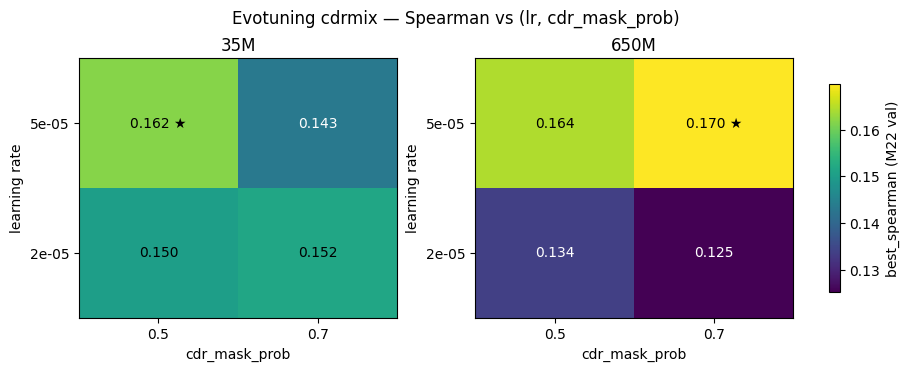

In [43]:
# === Evotuning cdrmix: hyperparameter sweep (best_spearman on M22 val) ===
# Numbers collected from finished runs on $TRAIN_DIR on 2026-06-23:
#   650M: cdrmix_v2_lr*_cmp*_2026061*       (freeze 24 layers)
#   35M : cdrmix_v2_35m_lr*_cmp*_20260623   (no freeze, seeded from oas_full_evo_35m)
# best_spearman = masked-position Spearman on ED2/M22 val (best_spearman.pt
# selection criterion); test = masked-position Spearman on M22 held-out test.
sweep = [
    # size,   lr,    cmp,  best_spearman(val), test(M22 held-out)
    ("35M",  5e-5,  0.5,  0.1616, 0.1705),
    ("35M",  5e-5,  0.7,  0.1432, 0.1357),
    ("35M",  2e-5,  0.5,  0.1502, 0.1528),
    ("35M",  2e-5,  0.7,  0.1516, 0.1352),
    ("650M", 5e-5,  0.5,  0.1644, 0.1483),
    ("650M", 5e-5,  0.7,  0.1697, 0.1649),
    ("650M", 2e-5,  0.5,  0.1337, 0.1270),
    ("650M", 2e-5,  0.7,  0.1253, 0.1253),
]
cdf = pd.DataFrame(sweep, columns=["size", "lr", "cmp", "best_spearman", "test_spearman"])

# readable table: best_spearman per (size, lr) x cmp
display(cdf.assign(lr=cdf["lr"].map(lambda x: f"{x:.0e}"))
           .pivot_table(index=["size", "lr"], columns="cmp", values="best_spearman")
           .round(4))

# lr x cmp heatmap per size (metric = best_spearman, the selection criterion)
sizes = ["35M", "650M"]
lrs = sorted(cdf["lr"].unique(), reverse=True)   # 5e-5 on top
cmps = sorted(cdf["cmp"].unique())
vmin, vmax = cdf["best_spearman"].min(), cdf["best_spearman"].max()

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), constrained_layout=True)
for ax, size in zip(axes, sizes):
    M = np.full((len(lrs), len(cmps)), np.nan)
    for _, r in cdf[cdf["size"] == size].iterrows():
        M[lrs.index(r["lr"]), cmps.index(r["cmp"])] = r["best_spearman"]
    im = ax.imshow(M, cmap="viridis", vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(cmps))); ax.set_xticklabels([f"{c:g}" for c in cmps])
    ax.set_yticks(range(len(lrs)));  ax.set_yticklabels([f"{l:.0e}" for l in lrs])
    ax.set_xlabel("cdr_mask_prob"); ax.set_ylabel("learning rate"); ax.set_title(size)
    best = M == np.nanmax(M)
    for i in range(len(lrs)):
        for j in range(len(cmps)):
            if np.isnan(M[i, j]):
                continue
            star = " ★" if best[i, j] else ""
            ax.text(j, i, f"{M[i, j]:.3f}{star}", ha="center", va="center",
                    color="white" if M[i, j] < (vmin + vmax) / 2 else "black", fontsize=10)
fig.colorbar(im, ax=axes, shrink=0.8, label="best_spearman (M22 val)")
fig.suptitle("Evotuning cdrmix — Spearman vs (lr, cdr_mask_prob)")
out = REPO_ROOT / "report" / "figures" / "cdrmix_sweep_spearman.pdf"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, bbox_inches="tight"); print("Saved:", out)
plt.show()

---
## Embedding probe learning curve — is the binding signal more linearly accessible after evotuning?

**How it works.** A frozen-backbone **linear probe**: for each (model, DMS
dataset) pair we cache the model's CDR-H3 embedding (ESM2 encoder, no
gradients, last hidden state **mean-pooled over the 24 CDR-H3 token
positions** only — the framework is constant across sequences) for every
sequence in the dataset, then fit a **Ridge regression** (features
standardized) to predict the experimental binding **enrichment** (the DMS
readout, not a model score) from that embedding. Spearman ρ between
predicted and true enrichment on a held-out test split is the figure of
merit.

The full-data probe saturates above ~50k labels — every backbone reaches
the same ρ once there is enough data for *any* linear map to extract the
signal, so representation differences wash out. To see whether evotuning
makes the binding signal *more directly readable* at small label budgets —
the regime that matters for a DPO starting checkpoint — the **learning
curve** repeats the same Ridge fit on **random subsamples of the train
split** (sizes 25…5000, 5 reseeded repeats each), always scored on the
**same fixed test split**.

**Data used.** Same DMS evaluation sets as the rest of the report
(`conf/analysis/dms_datasets.yaml`): `ed2_m22` / `ed5_m22` / `ed811_m22`
(M22 scorer) and `ed2_si06` / `ed5_si06` (SI06 scorer), each with its
train/test split, plus `exp`. Models compared: `vanilla_650m` (untouched
ESM2-650M) vs. the two C05-cdrmix evotuned checkpoints from the sweep
above (`evo_c05_cdrmix` = best `.pt` by val loss, `evo_c05_cdrmix_spearman`
= best `.pt` by masked Spearman).

**What it represents.** A model whose curve sits higher at small N
organizes the binding signal more linearly in its frozen embedding space →
it should need fewer labelled pairs to reach a given probe quality when
used as the DPO starting checkpoint. Computed by `sbatch
bash_scripts/probe.sbatch --mode curve`; pipeline in
`protein_design.analysis.figures.probe_learning_curve` /
`plot_learning_curve` (`report/figures/learning_curve.csv` /
`learning_curve.pdf`).

Saved: /cluster/home/mdenegri/protein-design/report/figures/learning_curve.pdf


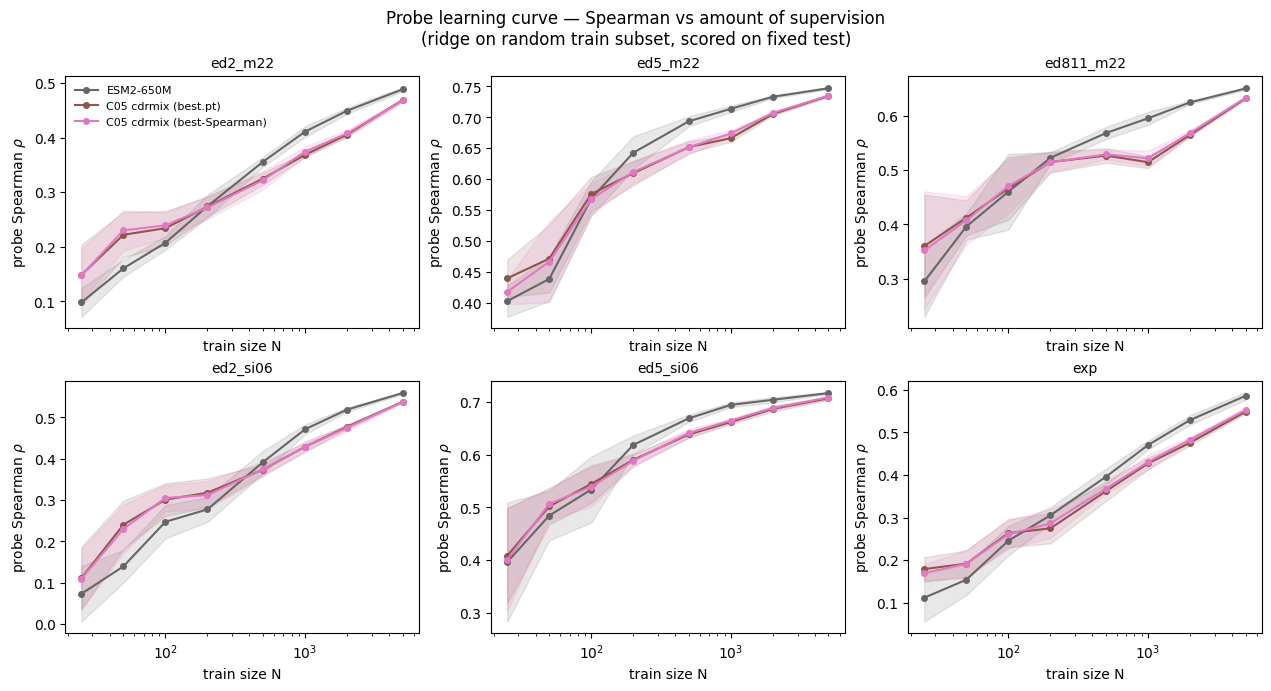

In [44]:
# === Embedding probe learning curve: recreate the plot ==============
# Reads the cached results (computed via `sbatch bash_scripts/probe.sbatch
# --mode curve`); does not recompute the probe. One panel per DMS dataset,
# one line per model: mean ridge Spearman (fixed test split) vs train-set
# size N (random subsample of the train split, 5 reseeded repeats), shaded
# band = +/-1 std across repeats.
lc_csv = REPO_ROOT / "report" / "figures" / "learning_curve.csv"
lc = pd.read_csv(lc_csv)

ds_keys = list(lc["dataset"].unique())
model_keys = list(lc["model"].unique())

ncols = min(3, len(ds_keys))
nrows = -(-len(ds_keys) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.4 * nrows),
                         constrained_layout=True, squeeze=False, sharex=True)
for ax, ds in zip(axes.flat, ds_keys):
    for i, mk in enumerate(model_keys):
        sub = lc[(lc["model"] == mk) & (lc["dataset"] == ds)].sort_values("n_train")
        if sub.empty:
            continue
        color = model_color(mk, i)
        ax.plot(sub["n_train"], sub["ridge_spearman_mean"], marker="o", ms=4,
                color=color, label=model_label(mk))
        ax.fill_between(sub["n_train"],
                        sub["ridge_spearman_mean"] - sub["ridge_spearman_std"],
                        sub["ridge_spearman_mean"] + sub["ridge_spearman_std"],
                        color=color, alpha=0.15)
    ax.set_xscale("log")
    ax.set_title(ds, fontsize=10)
    ax.set_xlabel("train size N")
    ax.set_ylabel(r"probe Spearman $\rho$")
for ax in axes.flat[len(ds_keys):]:
    ax.set_visible(False)
axes.flat[0].legend(fontsize=8, frameon=False)
fig.suptitle("Probe learning curve — Spearman vs amount of supervision\n"
             "(ridge on random train subset, scored on fixed test)")
out = REPO_ROOT / "report" / "figures" / "learning_curve.pdf"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, bbox_inches="tight"); print("Saved:", out)
plt.show()

## Choose what to plot

- `MODELS`: which models to show. Models with no completed runs (e.g. still
  training) are **automatically ignored** with a warning.
- `TEST_SETS`: which held-out sets to include in the **numeric table** below
  (`ed2`, `ed5`, or both). The plots are **per held-out set** (one dedicated
  cell for ed2 and one for ed5).

In [45]:
MODELS = sorted(runs_df["model"].unique())   # default: all available
# e.g. MODELS = ["vanilla_35m", "evo_35m", "evo_c05_blosum25", "evo_c05_cdrmix_35m"]

TEST_SETS = ["ed2", "ed5"]                   # subset of {"ed2", "ed5"}

MIN_SEEDS = 1                                # minimum seeds to draw a point at N
MODELS, TEST_SETS

(['evo_35m', 'evo_c05_blosum25', 'evo_c05_cdrmix_35m', 'vanilla_35m'],
 ['ed2', 'ed5'])

In [ ]:
# === learning curve plot (function only) ===========================
# NOTE: this cell DEFINES plot_curve, used by the dedicated ed2/ed5 cells below.
# The combined ed2+ed5 plot was removed (not informative); see the per-held-out cells.
LINESTYLE = {"ed2": "-", "ed5": "--"}

def plot_curve(models, test_sets=TEST_SETS, df=runs_df, metric=METRIC,
               min_seeds=MIN_SEEDS, zero_shot_df=None, save=True, show=True):
    fin = df[pd.to_numeric(df[metric], errors="coerce").notna()].copy()
    fin[metric] = pd.to_numeric(fin[metric])
    avail_ts = [t for t in test_sets if t in set(fin["test_set"])]
    ignored_ts = [t for t in test_sets if t not in avail_ts]
    if ignored_ts:
        print("Ignored test sets (no runs):", ignored_ts)

    fig, ax = plt.subplots(figsize=(8, 5))
    used_models, used_ts = [], []
    for i, mk in enumerate(models):
        color = model_color(mk, i)
        for ts in avail_ts:
            sub = fin[(fin["model"] == mk) & (fin["test_set"] == ts)]
            if sub.empty:
                continue
            agg = (sub.groupby("n_train")[metric]
                      .agg(mean="mean", std="std", n="size").reset_index()
                      .sort_values("n_train"))
            agg = agg[agg["n"] >= min_seeds]
            if agg.empty:
                continue
            ax.plot(agg["n_train"], agg["mean"], marker="o", color=color,
                    ls=LINESTYLE.get(ts, "-"))
            std = agg["std"].fillna(0.0)
            ax.fill_between(agg["n_train"], agg["mean"] - std, agg["mean"] + std,
                            color=color, alpha=0.12)
            if mk not in used_models: used_models.append(mk)
            if ts not in used_ts: used_ts.append(ts)

    # Zero-shot baselines: horizontal dotted line per (model, test_set)
    has_zeroshot = False
    if zero_shot_df is not None and not zero_shot_df.empty:
        zs_fin = zero_shot_df[pd.to_numeric(zero_shot_df[metric], errors="coerce").notna()].copy()
        zs_fin[metric] = pd.to_numeric(zs_fin[metric])
        for i, mk in enumerate(used_models):
            color = model_color(mk, models.index(mk))
            for ts in avail_ts:
                sub = zs_fin[(zs_fin["model"] == mk) & (zs_fin["test_set"] == ts)]
                if sub.empty:
                    continue
                zs_val = float(sub[metric].mean())
                ax.axhline(zs_val, color=color, ls=":", lw=1.5, alpha=0.85)
                has_zeroshot = True

    ignored_m = [m for m in models if m not in used_models]
    if ignored_m:
        print("Ignored models (no completed runs):", ignored_m)
    if not used_models:
        print("Nothing to plot.")
        plt.close(fig)
        return None

    ax.set_xscale("log")
    ax.set_xlabel("# training sequences (N)")
    ax.set_ylabel("Spearman (held-out test)")
    ax.set_title("DPO low-data learning curve")
    ax.axhline(0.0, color="0.7", lw=0.8, ls=":", zorder=0)
    ax.grid(True, which="both", alpha=0.2)

    # two legends: color = model, line style = test set (+ zero-shot if present)
    model_handles = [Line2D([0], [0], color=model_color(m, models.index(m)), lw=2,
                            label=model_label(m)) for m in used_models]
    ts_handles = [Line2D([0], [0], color="0.3", lw=2, ls=LINESTYLE.get(t, "-"),
                         label=f"{t} test") for t in used_ts]
    if has_zeroshot:
        ts_handles.append(Line2D([0], [0], color="0.3", lw=1.5, ls=":",
                                 label="zero-shot (no DPO)"))
    leg1 = ax.legend(handles=model_handles, frameon=False, fontsize=9, loc="upper left")
    ax.add_artist(leg1)
    ax.legend(handles=ts_handles, frameon=False, fontsize=9, loc="lower right")

    fig.tight_layout()
    if save:
        out = REPO_ROOT / "report" / "figures" / "dpo_lowdata_curve_meeting.pdf"
        out.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out, bbox_inches="tight")
        print("Saved:", out)
    if show:
        plt.show()
    return fig


## Dedicated plots (one per held-out)

Two ready-made cells: one for **ed2 test** and one for **ed5 test**. The scan
cell (above) re-reads data from disk every time it runs, so the **ed5 plot
fills in on its own** as missing jobs finish — just re-run the scan cell and
then the ed5 plot cell. Same for ed2.

In [ ]:
# === ed2 test ONLY =================================================
# (0.01 / 0.1 / 1 / 2 / 4 / 8 / 10 / 100 % of ed2 train =
#  N 22 / 220 / 2203 / 4406 / 8811 / 17623 / 22028 / 220283)
ED2_TRAIN_TOTAL = 220283  # sequences in the ed2_m22 train split
# show=False so the % axis is added BEFORE the figure is displayed
fig_ed2 = plot_curve(MODELS, test_sets=["ed2"], save=False, show=False,
                     zero_shot_df=zeroshot_df)
if fig_ed2 is not None:
    # secondary x axis as % of ed2 train (handy to talk in percentages)
    ax = fig_ed2.axes[0]
    ax.set_title("DPO low-data learning curve — ed2 test")
    secax = ax.secondary_xaxis(
        "top", functions=(lambda x: 100 * x / ED2_TRAIN_TOTAL,
                          lambda p: p * ED2_TRAIN_TOTAL / 100))
    secax.set_xlabel("% of ed2 train")
    out = REPO_ROOT / "report" / "figures" / "dpo_lowdata_curve_ed2.pdf"
    fig_ed2.savefig(out, bbox_inches="tight"); print("Saved:", out)
    plt.show()   # now the inline display includes the % axis


In [ ]:
# === ed5 test ONLY — points ≈ ED2 fractions (0.01/0.1/1/2/4/8/10/100%) ====
# ed5 has no runs at the exact ED2 fraction sizes, so we keep the NEAREST ed5 N:
#   50 ≈ 22 (0.01%), 200 ≈ 220 (0.1%), 2000 ≈ 2203 (1%),
#   4406 (2%), 8811 (4%), 17623 (8%), 22028 (10%), 220283 (100%).
# N is always a subsample of the ED2 train (220283) — only the TEST set is ed5 —
# so the secondary "% of ED2 train" axis is meaningful here too.
ED2_TRAIN_TOTAL = 220283
ED5_N = [50, 200, 2000, 4406, 8811, 17623, 22028, 220283]
df_ed5 = runs_df[runs_df["n_train"].isin(ED5_N)]
fig_ed5 = plot_curve(MODELS, test_sets=["ed5"], df=df_ed5, save=False, show=False,
                     zero_shot_df=zeroshot_df)
if fig_ed5 is not None:
    ax = fig_ed5.axes[0]
    ax.set_title("DPO low-data learning curve — ed5 test")
    secax = ax.secondary_xaxis(
        "top", functions=(lambda x: 100 * x / ED2_TRAIN_TOTAL,
                          lambda p: p * ED2_TRAIN_TOTAL / 100))
    secax.set_xlabel("% of ED2 train")
    out = REPO_ROOT / "report" / "figures" / "dpo_lowdata_curve_ed5.pdf"
    fig_ed5.savefig(out, bbox_inches="tight"); print("Saved:", out)
    plt.show()


In [ ]:
# === ed5 test ONLY — binders > wild type, points ≈ ED2 fractions ====
# Same as the ed5 cell above (nearest ED2-fraction N + % axis), but Spearman is
# computed ONLY over test sequences with binding enrichment > wild type
# (M22_binding_enrichment_adj > 0). Precomputed per run as 'test_spearman_avg_pos'
# (test.pos_threshold=0.0) — just re-scan that metric and reuse plot_curve.
POS_METRIC = "test_spearman_avg_pos"
runs_pos = scan_runs(metric=POS_METRIC)
zeroshot_pos = scan_zero_shot(metric=POS_METRIC)
ED2_TRAIN_TOTAL = 220283
ED5_N = [50, 200, 2000, 4406, 8811, 17623, 22028, 220283]
df_ed5_pos = runs_pos[runs_pos["n_train"].isin(ED5_N)]
fig_ed5_pos = plot_curve(MODELS, test_sets=["ed5"], df=df_ed5_pos, metric=POS_METRIC,
                         zero_shot_df=zeroshot_pos, save=False, show=False)
if fig_ed5_pos is not None:
    ax = fig_ed5_pos.axes[0]
    ax.set_title("DPO low-data — ed5 test, binders only (enrichment > WT)")
    ax.set_ylabel("Spearman (ed5 test, enrichment > WT)")
    secax = ax.secondary_xaxis(
        "top", functions=(lambda x: 100 * x / ED2_TRAIN_TOTAL,
                          lambda p: p * ED2_TRAIN_TOTAL / 100))
    secax.set_xlabel("% of ED2 train")
    out = REPO_ROOT / "report" / "figures" / "dpo_lowdata_curve_ed5_pos.pdf"
    fig_ed5_pos.savefig(out, bbox_inches="tight"); print("Saved:", out)
    plt.show()
